In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sqlite3
from scipy.stats import ttest_ind
import scipy.stats as stats

warnings.filterwarnings("ignore")

In [2]:
# creating database connection
conn = sqlite3.connect ('inventory.db')

In [3]:
import os 
print(os.getcwd())

C:\Users\AB


In [4]:
os.chdir(r"C:\Users\AB\Documents\projects")
print(os.getcwd())

C:\Users\AB\Documents\projects


In [5]:
import pandas as pd
import sqlite3

conn = sqlite3.connect("inventory.db")

tables = pd.read_sql(
    "SELECT name FROM sqlite_master WHERE type='table';",
    conn
)

print(tables)

                   name
0       begin_inventory
1         end_inventory
2             purchases
3       purchase_prices
4                 sales
5        vendor_invoice
6  vendor_sales_summary


In [6]:
# creating database connection
conn = sqlite3.connect("inventory.db")

# fetching vendor summary data
df = pd.read_sql_query(
    "SELECT * FROM vendor_sales_summary",
    conn
)

df.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5101919.51,672819.31,260999.20,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4819073.49,561512.37,294438.66,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4538120.60,461140.15,343854.07,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4475972.88,420050.01,368242.80,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4223107.62,545778.28,249587.83,1199901.61,28.412764,0.983556,1.396897


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,10692.0,1.065065e+04,18753.519148,2.00,3951.000000,7153.000000,9552.000000,2.013590e+05
Brand,10692.0,1.803923e+04,12662.187074,58.00,5793.500000,18761.500000,25514.250000,9.063100e+04
PurchasePrice,10692.0,2.438530e+01,109.269375,0.36,6.840000,10.455000,19.482500,5.681810e+03
ActualPrice,10692.0,3.564367e+01,148.246016,0.49,10.990000,15.990000,28.990000,7.499990e+03
Volume,10692.0,8.473605e+02,664.309212,50.00,750.000000,750.000000,750.000000,2.000000e+04
TotalPurchaseQuantity,10692.0,3.140887e+03,11095.086769,1.00,36.000000,262.000000,1975.750000,3.376600e+05
TotalPurchaseDollars,10692.0,3.010669e+04,123067.799627,0.71,453.457500,3655.465000,20738.245000,3.811252e+06
TotalSalesQuantity,10692.0,3.077482e+03,10952.851391,0.00,33.000000,261.000000,1929.250000,3.349390e+05
TotalSalesDollars,10692.0,4.223907e+04,167655.265984,0.00,729.220000,5298.045000,28396.915000,5.101920e+06
TotalSalesPrice,10692.0,1.879378e+04,44952.773386,0.00,289.710000,2857.800000,16059.562500,6.728193e+05


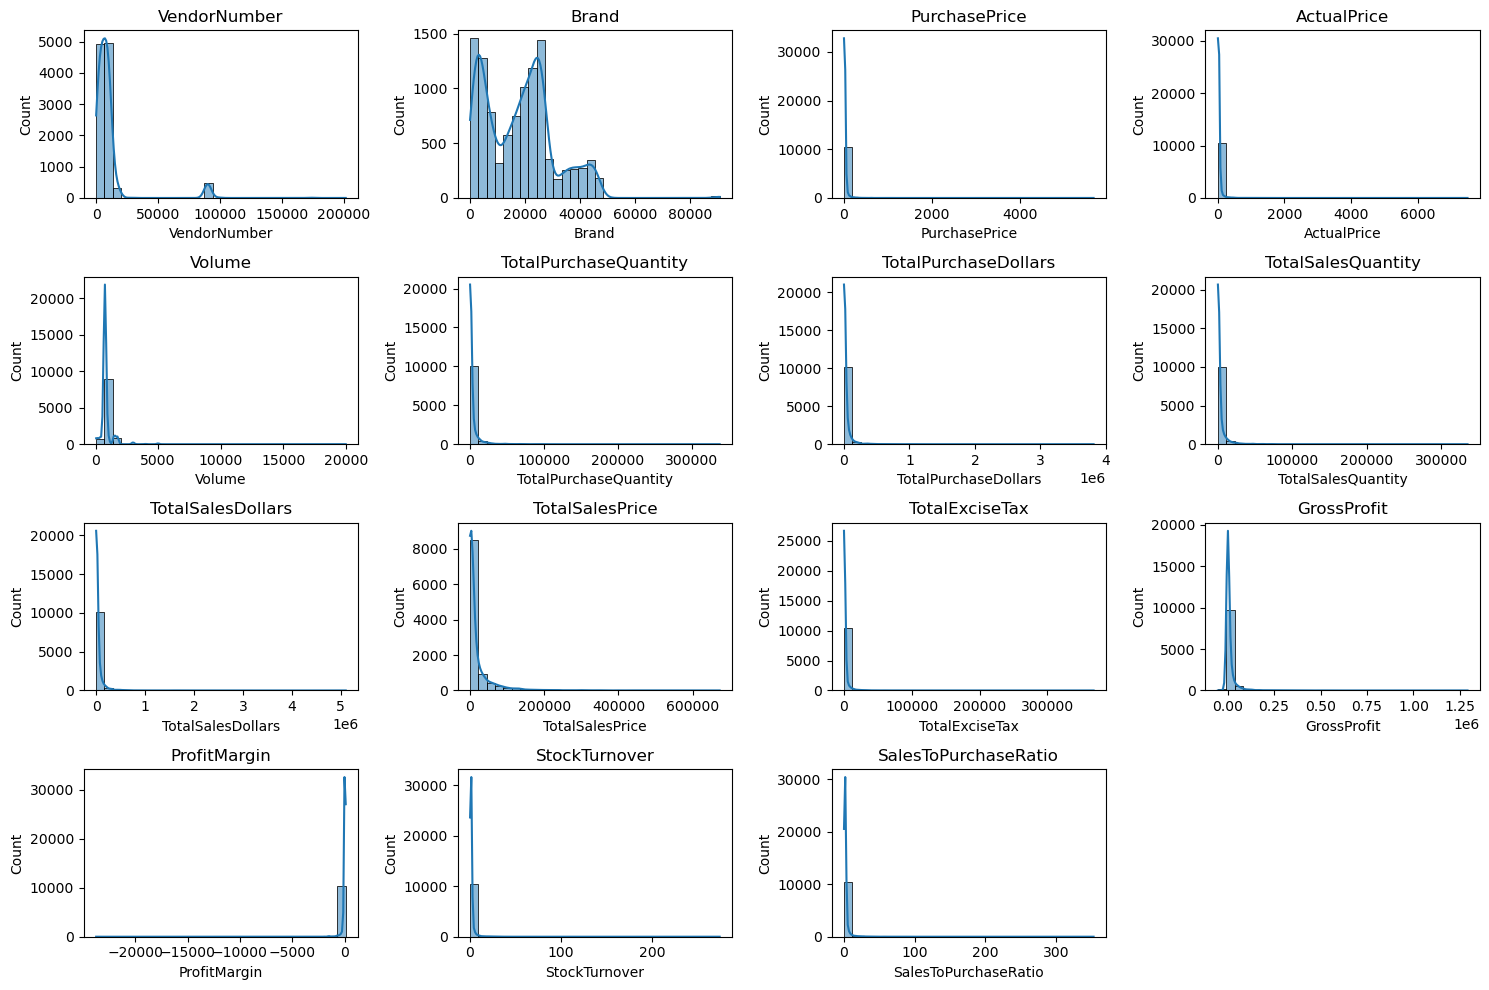

In [8]:
# Distribution Plots for Numerical Columns

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 10))

for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i + 1)  # Adjust grid layout if needed
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)

plt.tight_layout()
plt.show()

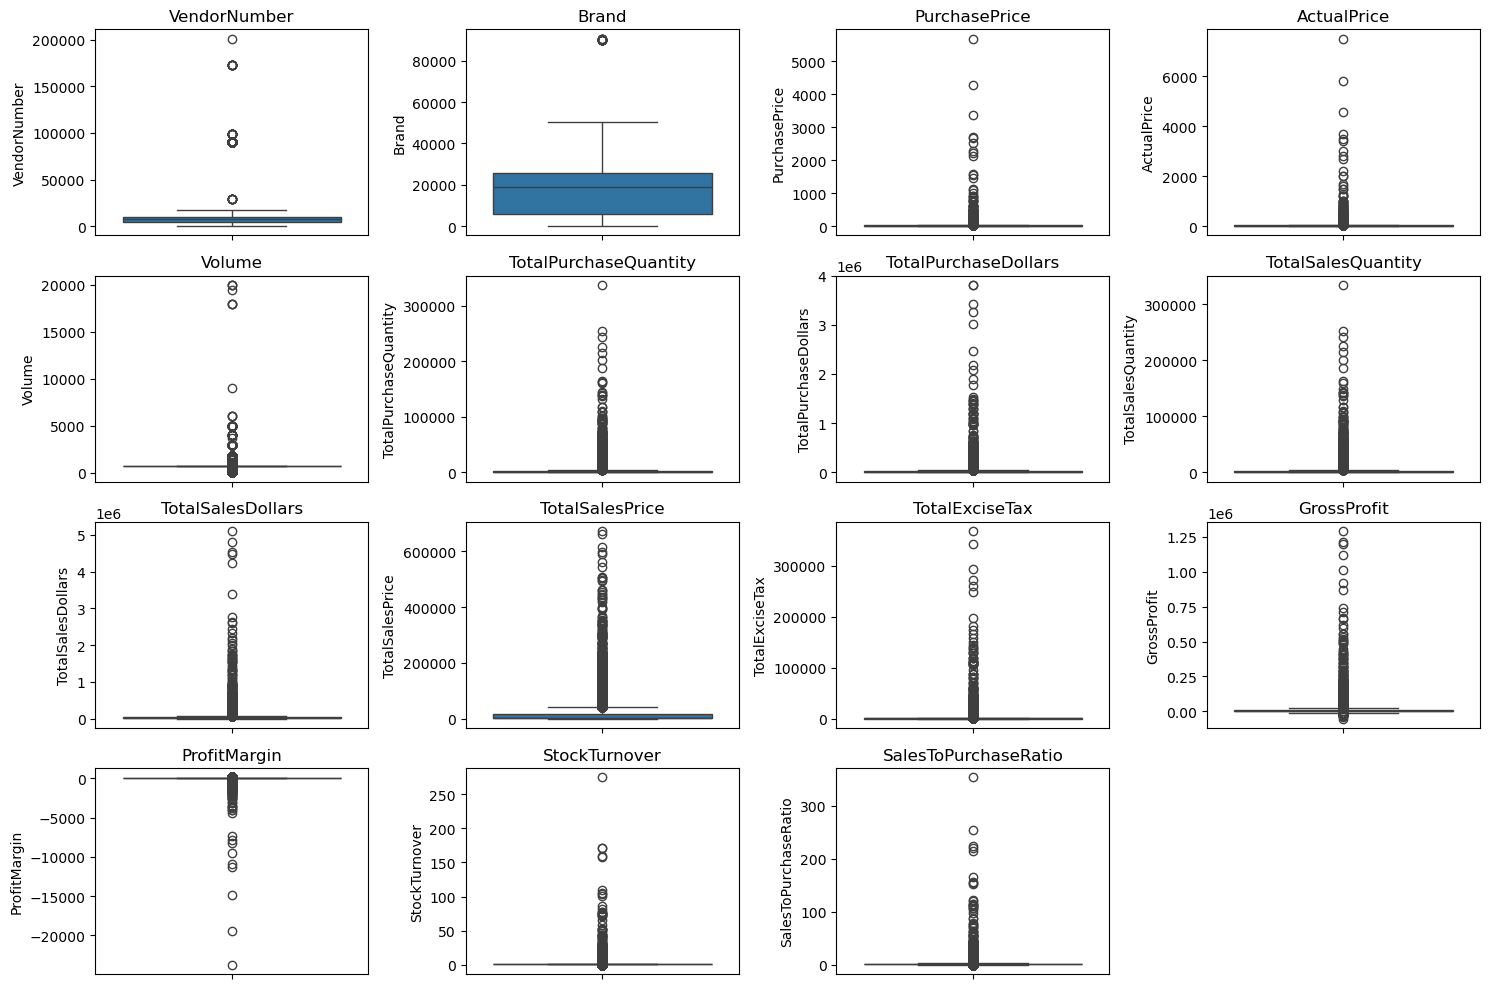

In [9]:
# Outlier Detection with Boxplots

plt.figure(figsize=(15, 10))

for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i + 1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

# Summary Statistics Insights

## Negative & Zero Values

- *Gross Profit*: Minimum value is -52,002.78, indicating losses. Some products or transactions are selling at a loss due to high costs or discounts below purchase price.  
- *Profit Margin*: Minimum is 0, suggesting cases where revenue is zero or lower than costs.  
- *Total Sales Quantity & Sales Dollars*: Minimum values are 0, meaning some products were purchased but never sold — possibly slow-moving or obsolete stock.  

## Outliers Indicated by High Standard Deviations

- *Purchase & Actual Prices*: Maximum values (5,681.81 & 7,499.99) are much higher than the mean (24.39 & 35.64), indicating premium or high-value products.  
- *Freight Cost*: Huge variation from 0.09 to 257,032.07 suggests logistics inefficiencies or bulk shipments.  
- *Stock Turnover*: Ranges from 0 to 274.5, showing that some products sell extremely fast while others remain in stock indefinitely.  
- *Values above 1* indicate that sold quantity for a product is higher than purchased quantity, possibly because sales are being fulfilled from older stock.

In [10]:
# Filter the data by removing inconsistencies
df = pd.read_sql_query("""
    SELECT *
    FROM vendor_sales_summary
    WHERE GrossProfit > 0
      AND ProfitMargin > 0
      AND TotalSalesQuantity > 0""", conn)

In [11]:
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5101919.51,672819.31,260999.20,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4819073.49,561512.37,294438.66,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4538120.60,461140.15,343854.07,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4475972.88,420050.01,368242.80,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4223107.62,545778.28,249587.83,1199901.61,28.412764,0.983556,1.396897
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8559,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.0,2,2.64,5.0,15.95,10.96,0.55,13.31,83.448276,2.500000,6.041667
8560,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.0,6,2.34,134.0,65.66,1.47,7.04,63.32,96.436186,22.333333,28.059829
8561,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.74,0.99,50.0,2,1.48,2.0,1.98,0.99,0.10,0.50,25.252525,1.000000,1.337838
8562,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200.0,1,1.47,72.0,143.28,77.61,15.12,141.81,98.974037,72.000000,97.469388


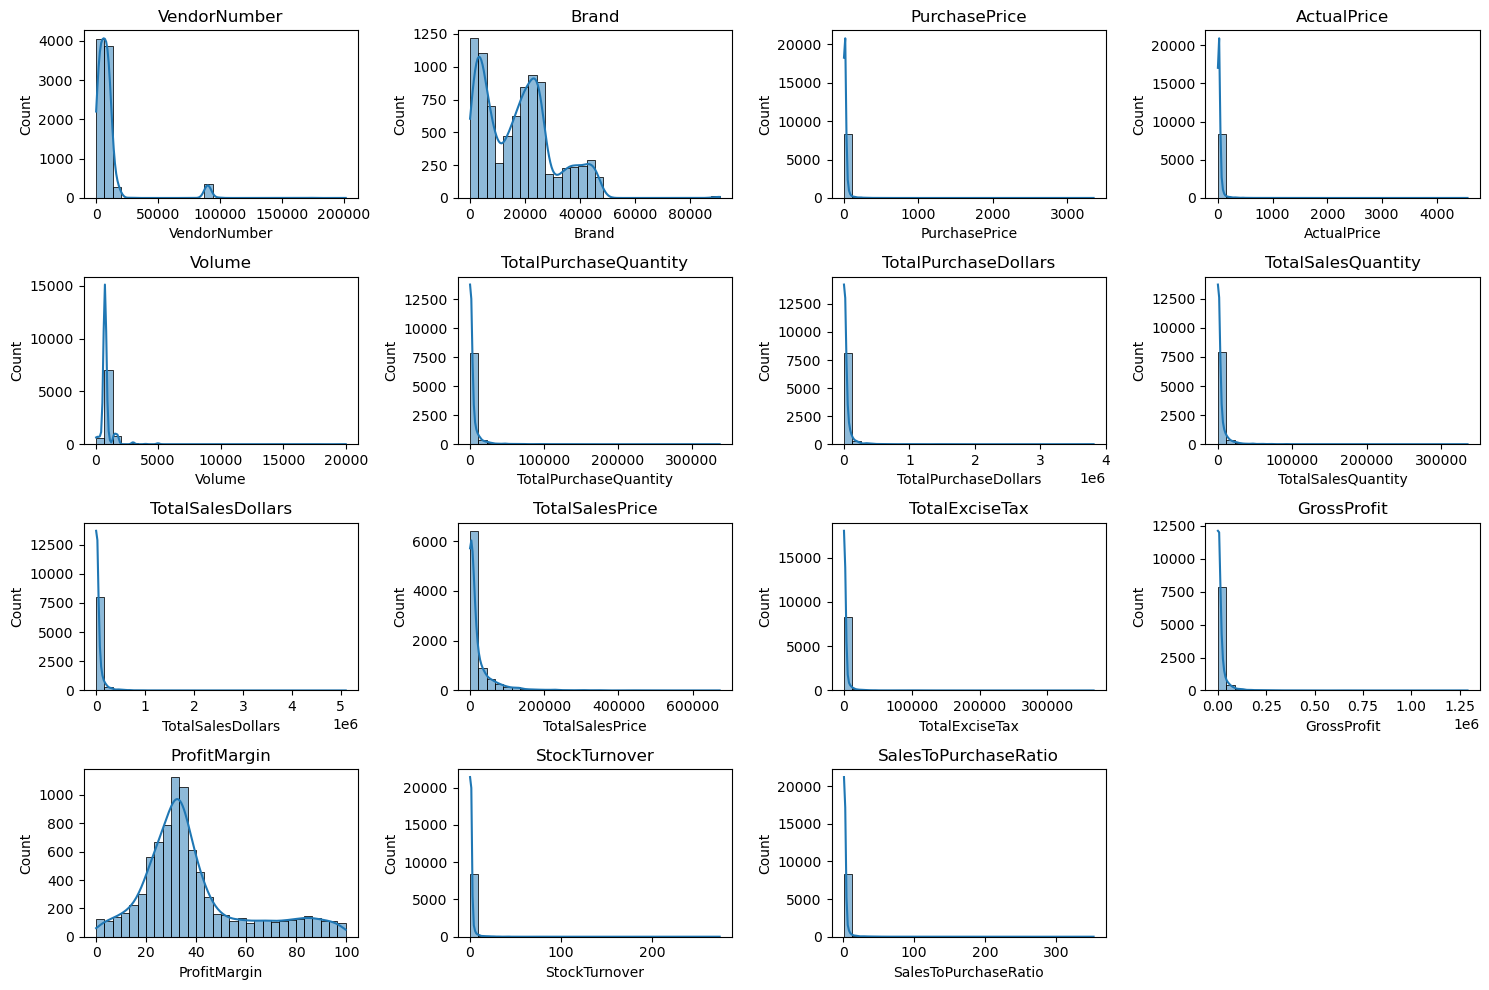

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 10))

for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i + 1)  # Adjust grid layout if needed
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)

plt.tight_layout()
plt.show()

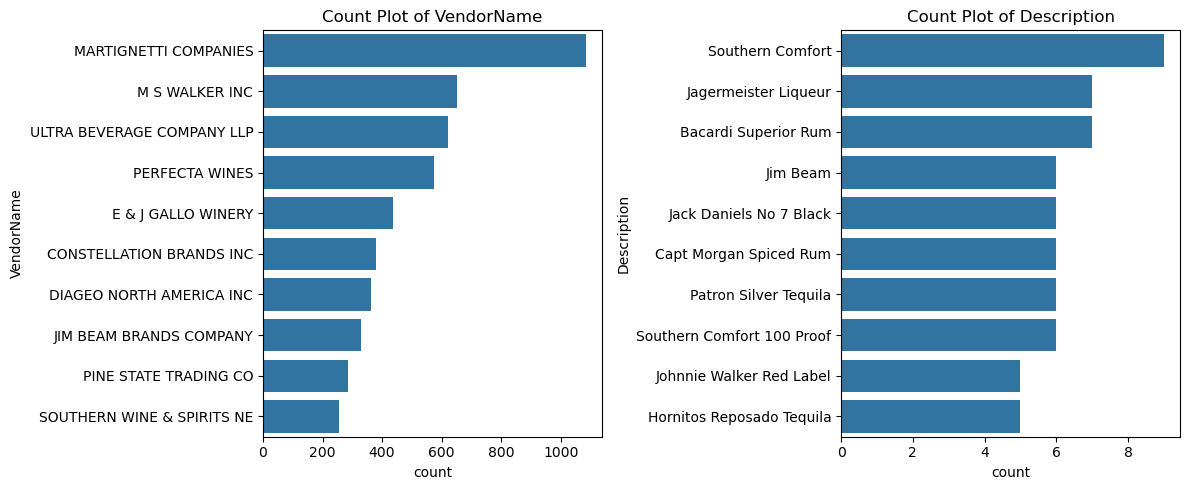

In [13]:
# Count Plots for Categorical Columns

categorical_cols = ["VendorName", "Description"]

plt.figure(figsize=(12, 5))

for i, col in enumerate(categorical_cols):
    plt.subplot(1, 2, i + 1)
    sns.countplot(
        y=df[col], 
        order=df[col].value_counts().iloc[:10].index  # Top 10 categories
    )
    plt.title(f"Count Plot of {col}")

plt.tight_layout()
plt.show()

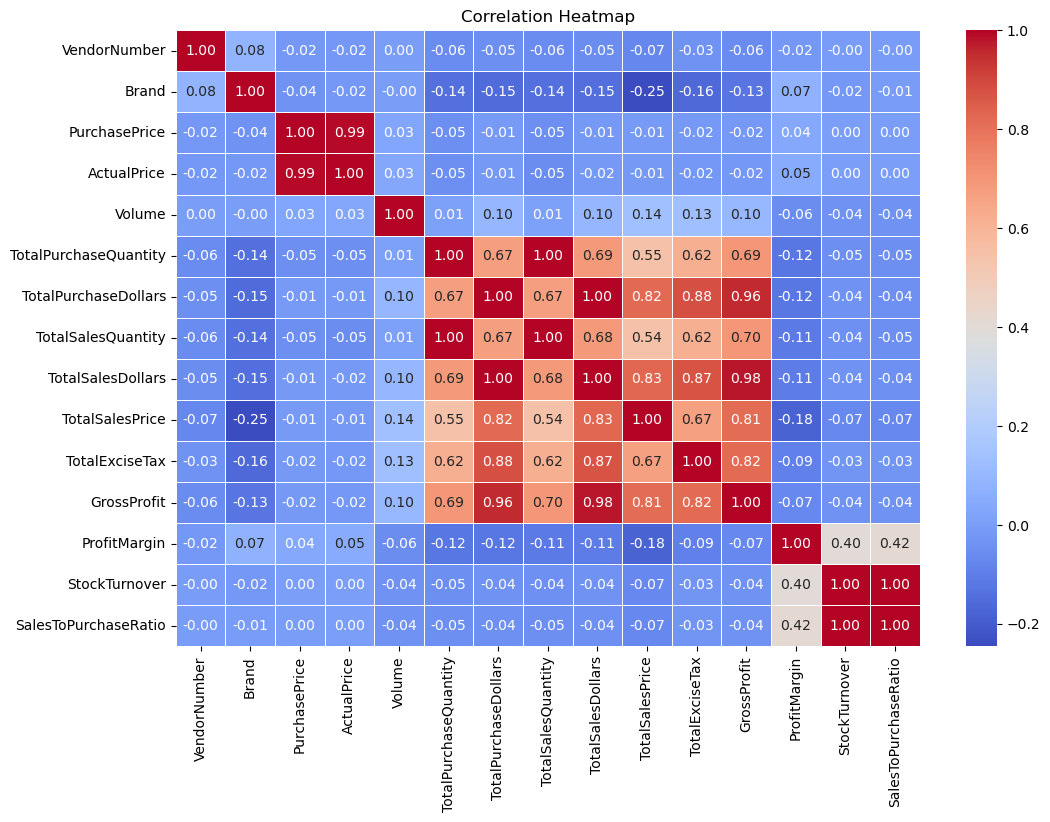

In [14]:
plt.figure(figsize=(12, 8))

correlation_matrix = df[numerical_cols].corr()

sns.heatmap(
    correlation_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm", 
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

# Correlation Insights

- *Purchase Price* has weak correlations with *TotalSalesDollars (-0.012)* and *GrossProfit (-0.016)*, suggesting that price variations do not significantly impact sales revenue or profit.

- There is a *strong positive correlation (0.999)* between *TotalPurchaseQuantity* and *TotalSalesQuantity*, confirming efficient inventory turnover.

- A *negative correlation (-0.179)* between *ProfitMargin* and *TotalSalesPrice* suggests that as sales price increases, margins decrease — possibly due to competitive pricing pressures.

- *StockTurnover* has weak negative correlations with both *GrossProfit (-0.038)* and *ProfitMargin (-0.055)*, indicating that faster turnover does not necessarily result in higher profitability.

---

# Data Analysis Objective

## Identify Brands for Promotional or Pricing Adjustments

The goal is to identify brands that:

- Exhibit *lower sales performance*
- Maintain *higher profit margins*

These brands represent potential opportunities for:
- Increased marketing efforts  
- Promotional campaigns  
- Strategic pricing adjustments  

Improving visibility or adjusting pricing for these brands could significantly enhance overall revenue while maintaining profitability.

In [15]:
# Group by Description and aggregate
brand_performance = df.groupby('Description').agg({
    'TotalSalesDollars': 'sum',
    'ProfitMargin': 'mean'}).reset_index()

In [16]:
low_sales_threshold = brand_performance ['TotalSalesDollars'].quantile(0.15)
high_margin_threshold = brand_performance ['ProfitMargin'].quantile(0.85)

In [17]:
low_sales_threshold

np.float64(560.299)

In [18]:
high_margin_threshold

np.float64(64.97017552750113)

In [19]:
# Filter brands with low sales but high profit margins

low_sales_threshold = 1000   # example value, set as needed
high_margin_threshold = 20    # example value in percent, set as needed

target_brands = brand_performance[
    (brand_performance['TotalSalesDollars'] <= low_sales_threshold) &
    (brand_performance['ProfitMargin'] >= high_margin_threshold)
]

print("Brands with Low Sales but High Profit Margins:")
display(target_brands.sort_values('TotalSalesDollars'))

Brands with Low Sales but High Profit Margins:


,Description,TotalSalesDollars,ProfitMargin
6942,Terruzzi & Puthod Vernaccia,4.99,32.464930
2897,Firefly Ridge Chard,5.79,31.088083
148,Albero Sparkling Wh Organic,5.79,28.497409
6488,Smirnoff Light Strawberry,5.94,50.168350
178,Allen's Blue Curacao Liqueur,5.99,20.033389
...,...,...,...
3476,Hartford Court Chard RRV,998.61,49.259471
6687,Steph Avrn Chn Vielles Vig,999.50,97.278639
4685,Marques de Grinon 10 Cab Svg,999.75,83.783946
3125,Galerie Latro Cab S Knights,999.80,93.332667


In [20]:
brand_performance= brand_performance [brand_performance ['TotalSalesDollars'] <10000] # for better visualization

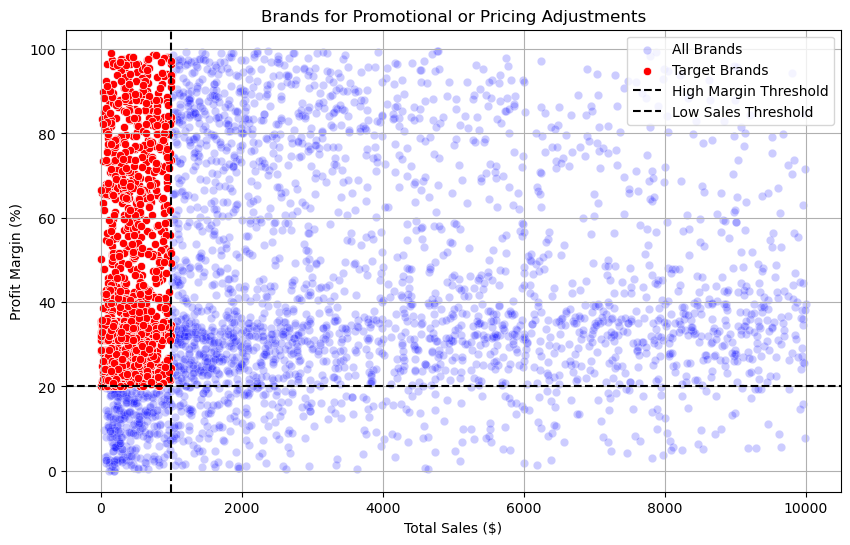

In [21]:
# Scatter plot: Total Sales vs Profit Margin

plt.figure(figsize=(10, 6))

# All brands in blue
sns.scatterplot(
    data=brand_performance, 
    x='TotalSalesDollars', 
    y='ProfitMargin', 
    color="blue", 
    label="All Brands", 
    alpha=0.2
)

# Target brands in red
sns.scatterplot(
    data=target_brands, 
    x='TotalSalesDollars', 
    y='ProfitMargin', 
    color="red", 
    label="Target Brands"
)

# Threshold lines
plt.axhline(high_margin_threshold, linestyle='--', color='black', label="High Margin Threshold")
plt.axvline(low_sales_threshold, linestyle='--', color='black', label="Low Sales Threshold")

plt.xlabel("Total Sales ($)")
plt.ylabel("Profit Margin (%)")
plt.title("Brands for Promotional or Pricing Adjustments")
plt.legend()
plt.grid(True)
plt.show()

#Which vendors and Brands demonstrate the highest sales performance?

In [22]:
def format_dollars(value):
    if value>= 1_000_000:
        return f"{value / 1_000_000:.2f}M"
    elif value>= 1_000:
        return f"{value / 1_000:.2f}K"
    else:
        return str(value)

In [23]:
# Top Vendors & Brands by Sales Performance

# Top 10 Vendors by Total Sales
top_vendors = df.groupby("VendorName")["TotalSalesDollars"].sum().nlargest(10)

# Top 10 Brands/Products by Total Sales
top_brands = df.groupby("Description")["TotalSalesDollars"].sum().nlargest(10)

# Display results
print("Top 10 Vendors by Sales:")
display(top_vendors)

print("\nTop 10 Brands/Products by Sales:")
display(top_brands)

Top 10 Vendors by Sales:


VendorName
DIAGEO NORTH AMERICA INC      67990099.42
MARTIGNETTI COMPANIES         39330359.36
PERNOD RICARD USA             32063196.19
JIM BEAM BRANDS COMPANY       31423020.46
BACARDI USA INC               24854817.14
CONSTELLATION BRANDS INC      24218745.65
E & J GALLO WINERY            18399899.46
BROWN-FORMAN CORP             18247230.65
ULTRA BEVERAGE COMPANY LLP    16502544.31
M S WALKER INC                14706458.51
Name: TotalSalesDollars, dtype: float64


Top 10 Brands/Products by Sales:


Description
Jack Daniels No 7 Black    7964746.76
Tito's Handmade Vodka      7399657.58
Grey Goose Vodka           7209608.06
Capt Morgan Spiced Rum     6356320.62
Absolut 80 Proof           6244752.03
Jameson Irish Whiskey      5715759.69
Ketel One Vodka            5070083.56
Baileys Irish Cream        4150122.07
Kahlua                     3604858.66
Tanqueray                  3456697.90
Name: TotalSalesDollars, dtype: float64

In [24]:
top_brands

Description
Jack Daniels No 7 Black    7964746.76
Tito's Handmade Vodka      7399657.58
Grey Goose Vodka           7209608.06
Capt Morgan Spiced Rum     6356320.62
Absolut 80 Proof           6244752.03
Jameson Irish Whiskey      5715759.69
Ketel One Vodka            5070083.56
Baileys Irish Cream        4150122.07
Kahlua                     3604858.66
Tanqueray                  3456697.90
Name: TotalSalesDollars, dtype: float64

In [25]:
top_brands.apply(lambda x : format_dollars(x))

Description
Jack Daniels No 7 Black    7.96M
Tito's Handmade Vodka      7.40M
Grey Goose Vodka           7.21M
Capt Morgan Spiced Rum     6.36M
Absolut 80 Proof           6.24M
Jameson Irish Whiskey      5.72M
Ketel One Vodka            5.07M
Baileys Irish Cream        4.15M
Kahlua                     3.60M
Tanqueray                  3.46M
Name: TotalSalesDollars, dtype: object

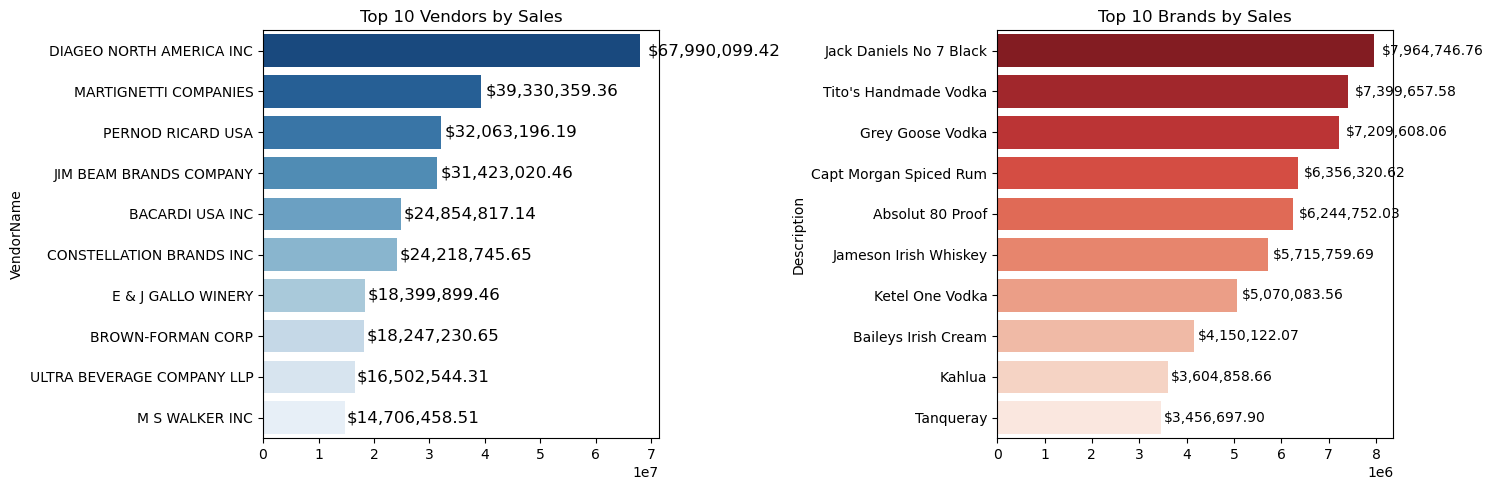

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Example: format function for dollars
def format_dollars(x):
    return f"${x:,.2f}"

plt.figure(figsize=(15,5))

# ---------------- Top Vendors ----------------
plt.subplot(1, 2, 1)
ax1 = sns.barplot(y=top_vendors.index, x=top_vendors.values, palette="Blues_r")
plt.title("Top 10 Vendors by Sales")

# Add labels on bars
for bar in ax1.patches:
    ax1.text(
        bar.get_width() + (bar.get_width() * 0.02),
        bar.get_y() + bar.get_height() / 2,
        format_dollars(bar.get_width()),
        ha='left', va='center',
        fontsize=12, color='black'
    )

# ---------------- Top Brands ----------------
plt.subplot(1, 2, 2)
ax2 = sns.barplot(y=top_brands.index.astype(str), x=top_brands.values, palette="Reds_r")
plt.title("Top 10 Brands by Sales")

# Add labels on bars
for bar in ax2.patches:
    ax2.text(
        bar.get_width() + (bar.get_width() * 0.02),
        bar.get_y() + bar.get_height() / 2,
        format_dollars(bar.get_width()),
        ha='left', va='center',
        fontsize=10, color='black'
    )

plt.tight_layout()
plt.show()

#Which vendors contribute the most to total purchase dollars?

In [27]:
vendor_performance= df.groupby('VendorName').agg({
    'TotalPurchaseDollars':'sum',
    'GrossProfit':'sum',
    'TotalSalesDollars':'sum'
}).reset_index()
vendor_performance.shape

(119, 4)

In [28]:
vendor_performance['PurchaseContribution%'] = vendor_performance['TotalPurchaseDollars']/ vendor_performance['TotalPurchaseDollars'].sum()*100

In [29]:
vendor_performance = round(vendor_performance.sort_values('PurchaseContribution%', ascending = False),2)

In [30]:
# Display Top 10 Vendors
top_vendors = vendor_performance.head(10)

top_vendors['TotalSalesDollars'] = top_vendors['TotalSalesDollars'].apply(format_dollars)
top_vendors['TotalPurchaseDollars'] = top_vendors['TotalPurchaseDollars'].apply(format_dollars)
top_vendors['GrossProfit'] = top_vendors['GrossProfit'].apply(format_dollars)

top_vendors


,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
25,DIAGEO NORTH AMERICA INC,"$50,097,226.16","$17,892,873.26","$67,990,099.42",16.30
57,MARTIGNETTI COMPANIES,"$25,502,095.83","$13,828,263.53","$39,330,359.36",8.30
68,PERNOD RICARD USA,"$23,851,164.17","$8,212,032.02","$32,063,196.19",7.76
46,JIM BEAM BRANDS COMPANY,"$23,494,304.32","$7,928,716.14","$31,423,020.46",7.64
6,BACARDI USA INC,"$17,432,020.26","$7,422,796.88","$24,854,817.14",5.67
20,CONSTELLATION BRANDS INC,"$15,273,708.08","$8,945,037.57","$24,218,745.65",4.97
11,BROWN-FORMAN CORP,"$13,238,939.18","$5,008,291.47","$18,247,230.65",4.31
30,E & J GALLO WINERY,"$12,068,539.22","$6,331,360.24","$18,399,899.46",3.93
106,ULTRA BEVERAGE COMPANY LLP,"$11,167,081.61","$5,335,462.70","$16,502,544.31",3.63
53,M S WALKER INC,"$9,764,312.60","$4,942,145.91","$14,706,458.51",3.18


In [31]:
top_vendors['PurchaseContribution%'] = top_vendors['PurchaseContribution%'].cumsum()
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
25,DIAGEO NORTH AMERICA INC,"$50,097,226.16","$17,892,873.26","$67,990,099.42",16.30
57,MARTIGNETTI COMPANIES,"$25,502,095.83","$13,828,263.53","$39,330,359.36",24.60
68,PERNOD RICARD USA,"$23,851,164.17","$8,212,032.02","$32,063,196.19",32.36
46,JIM BEAM BRANDS COMPANY,"$23,494,304.32","$7,928,716.14","$31,423,020.46",40.00
6,BACARDI USA INC,"$17,432,020.26","$7,422,796.88","$24,854,817.14",45.67
20,CONSTELLATION BRANDS INC,"$15,273,708.08","$8,945,037.57","$24,218,745.65",50.64
11,BROWN-FORMAN CORP,"$13,238,939.18","$5,008,291.47","$18,247,230.65",54.95
30,E & J GALLO WINERY,"$12,068,539.22","$6,331,360.24","$18,399,899.46",58.88
106,ULTRA BEVERAGE COMPANY LLP,"$11,167,081.61","$5,335,462.70","$16,502,544.31",62.51
53,M S WALKER INC,"$9,764,312.60","$4,942,145.91","$14,706,458.51",65.69


In [32]:
vendor_performance = df.groupby("VendorName").agg({
    "TotalSalesDollars": "sum",
    "TotalPurchaseDollars": "sum",
    "GrossProfit": "sum"
}).reset_index()

vendor_performance.head()

,VendorName,TotalSalesDollars,TotalPurchaseDollars,GrossProfit
0,ADAMBA IMPORTS INTL INC,704.53,446.16,258.37
1,ALISA CARR BEVERAGES,104470.94,25698.12,78772.82
2,ALTAMAR BRANDS LLC,15706.81,11706.20,4000.61
3,AMERICAN SPIRITS EXCHANGE,1511.16,934.08,577.08
4,AMERICAN VINTAGE BEVERAGE,139603.53,104435.68,35167.85


In [33]:
total_purchase = vendor_performance["TotalPurchaseDollars"].sum()
vendor_performance["Purchase_Contribution"] = (
    vendor_performance["TotalPurchaseDollars"] / total_purchase
) * 100

In [34]:
top_vendors = vendor_performance.sort_values(
    by="Purchase_Contribution",
    ascending=False
).head(10)

In [35]:
top_vendors['Cumulative_Contribution'] = top_vendors['Purchase_Contribution'].cumsum()

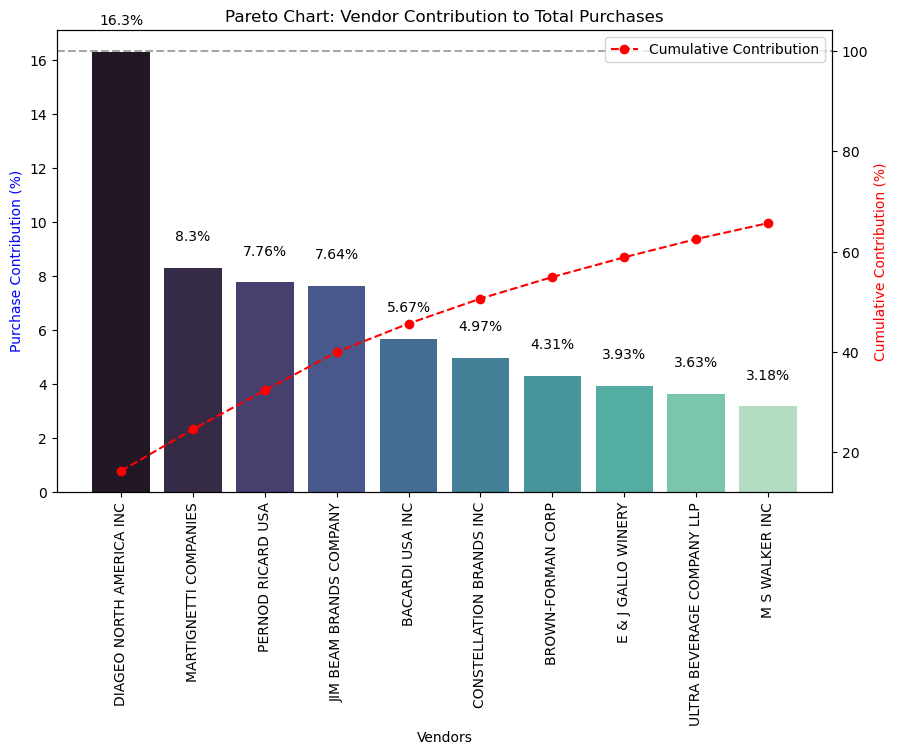

In [36]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar plot for Purchase Contribution %
sns.barplot(
    x=top_vendors['VendorName'],
    y=top_vendors['Purchase_Contribution'],
    palette="mako",
    ax=ax1
)

# Add percentage labels on bars
for i, value in enumerate(top_vendors['Purchase_Contribution']):
    ax1.text(i, value + 1, str(round(value, 2)) + '%',
             ha='center', fontsize=10, color='black')

# Line Plot for Cumulative Contribution %
ax2 = ax1.twinx()

ax2.plot(
    top_vendors['VendorName'],
    top_vendors['Cumulative_Contribution'],
    color='red',
    marker='o',
    linestyle='dashed',
    label='Cumulative Contribution'
)

ax1.set_xticklabels(top_vendors['VendorName'], rotation=90)

ax1.set_ylabel('Purchase Contribution (%)', color='blue')
ax2.set_ylabel('Cumulative Contribution (%)', color='red')

ax1.set_xlabel('Vendors')
ax1.set_title('Pareto Chart: Vendor Contribution to Total Purchases')

ax2.axhline(y=100, color='gray', linestyle='dashed', alpha=0.7)
ax2.legend(loc='upper right')

plt.show()

#How Much of total procurement is dependant on the top vendors?

In [37]:
print(f"Total Purchase Contribution of top 10 vendors is {round(top_vendors['Purchase_Contribution'].sum(), 2)}%")

Total Purchase Contribution of top 10 vendors is 65.69%


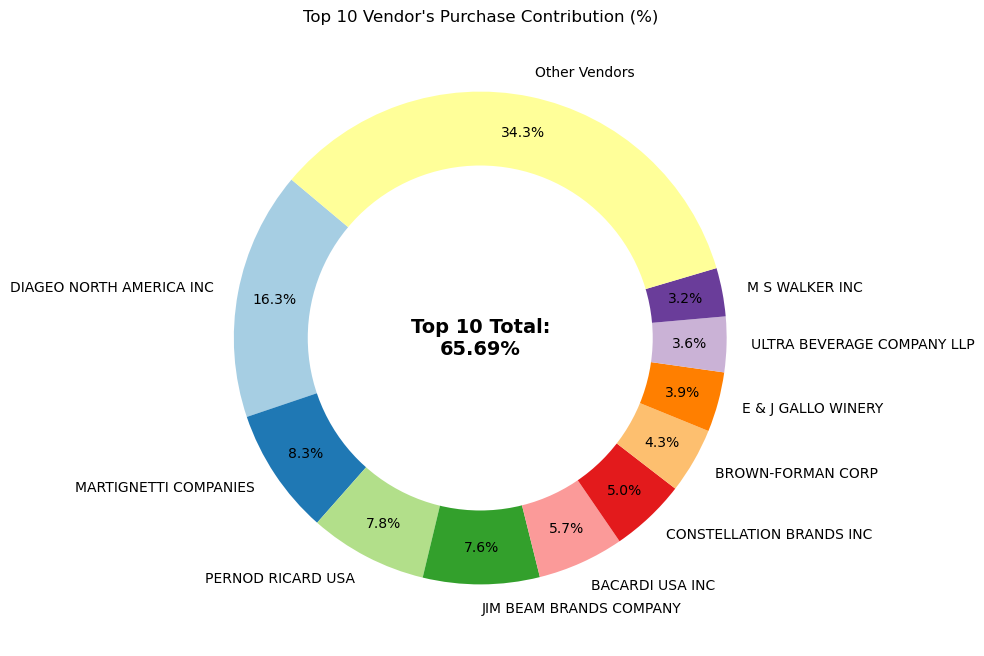

In [38]:
vendors = list(top_vendors['VendorName'].values)
purchase_contributions = list(top_vendors['Purchase_Contribution'].values)

total_contribution = sum(purchase_contributions)
remaining_contribution = 100 - total_contribution

# Append "Other Vendors"
vendors.append("Other Vendors")
purchase_contributions.append(remaining_contribution)

# Donut Chart
fig, ax = plt.subplots(figsize=(8, 8))

wedges, texts, autotexts = ax.pie(
    purchase_contributions,
    labels=vendors,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.85,
    colors=plt.cm.Paired.colors
)

# Create donut hole
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

# Add total contribution text
plt.text(
    0, 0,
    f"Top 10 Total:\n{total_contribution:.2f}%",
    fontsize=14,
    fontweight='bold',
    ha='center',
    va='center'
)

plt.title("Top 10 Vendor's Purchase Contribution (%)")

plt.show()

Does purchasing in bulk educe the unit price, and what is the optimal purchase volume for cost saving

In [39]:
df['UnitPurchasePrice'] = df['TotalPurchaseDollars'] / df['TotalPurchaseQuantity']

In [40]:
df["OrderSize"] = pd.qcut (df["TotalPurchaseQuantity"], q=3, labels=["Small", "Medium", "Large"])

In [41]:
df.groupby('OrderSize')[['UnitPurchasePrice']].mean()

,UnitPurchasePrice
OrderSize,
Small,39.068186
Medium,15.486414
Large,10.777625


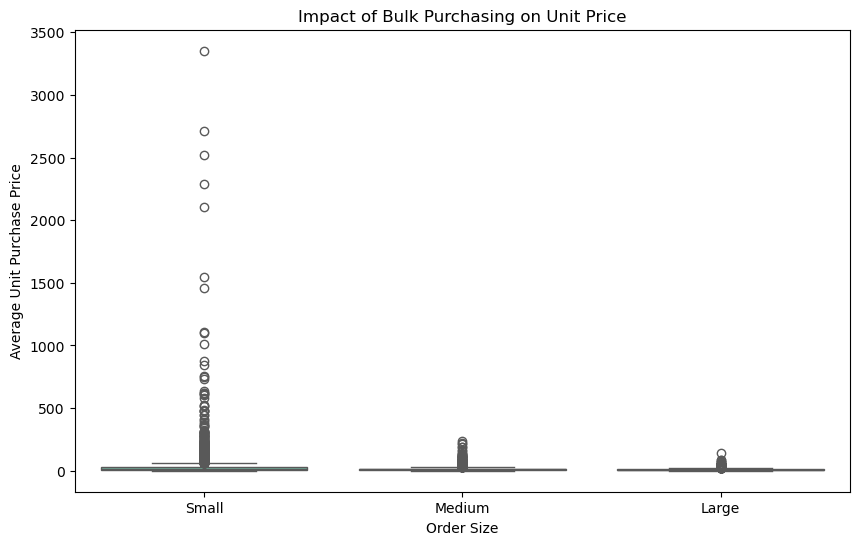

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df,
    x="OrderSize",
    y="UnitPurchasePrice",
    palette="Set2"
)
plt.title("Impact of Bulk Purchasing on Unit Price")
plt.xlabel("Order Size")
plt.ylabel("Average Unit Purchase Price")
plt.show()

- Vendors buying in bulk (Large Order Size) get the lowest unit price ($10.78 per unit), meaning higher margins if they can manage inventory efficiently.
- The price difference between Small and Large orders is substantial (-72% reduction in unit cost).
- Bulk pricing strategies encourage vendors to purchase larger volumes, leading to higher overall sales despite lower per-unit revenue.

**Which vendors have low inventory turnover, indicating excess stock and slow-moving products?**

In [43]:
df[df['StockTurnover']<1].groupby('VendorName')[['StockTurnover']].mean().sort_values('StockTurnover',ascending = True).head(10)

,StockTurnover
VendorName,
ALISA CARR BEVERAGES,0.615385
HIGHLAND WINE MERCHANTS LLC,0.708333
PARK STREET IMPORTS LLC,0.751306
Circa Wines,0.755676
Dunn Wine Brokers,0.766022
CENTEUR IMPORTS LLC,0.773953
SMOKY QUARTZ DISTILLERY LLC,0.783835
TAMWORTH DISTILLING,0.797078
THE IMPORTED GRAPE LLC,0.807569


**How much capital is locked in unsold inventory per vendor, and which vendors contribute the most to it?**

In [44]:
df["UnsoldInventoryValue"] = (df["TotalPurchaseQuantity"] - df["TotalSalesQuantity"]) * df["PurchasePrice"]

print('Total Unsold Capital:', format_dollars(df["UnsoldInventoryValue"].sum()))

Total Unsold Capital: $2,708,177.22


In [45]:
# Aggregate capital locked per vendor
inventory_value_per_vendor = df.groupby("VendorName")["UnsoldInventoryValue"].sum().reset_index()

# Sort vendors with highest locked capital
inventory_value_per_vendor = inventory_value_per_vendor.sort_values(by="UnsoldInventoryValue", ascending=False)

# Format values for readability
inventory_value_per_vendor['UnsoldInventoryValue'] = inventory_value_per_vendor['UnsoldInventoryValue'].apply(format_dollars)

# Show top 10 vendors
inventory_value_per_vendor.head(10)

,VendorName,UnsoldInventoryValue
25,DIAGEO NORTH AMERICA INC,"$722,209.05"
46,JIM BEAM BRANDS COMPANY,"$554,665.63"
68,PERNOD RICARD USA,"$470,625.61"
116,WILLIAM GRANT & SONS INC,"$401,960.83"
30,E & J GALLO WINERY,"$228,282.61"
79,SAZERAC CO INC,"$198,436.41"
11,BROWN-FORMAN CORP,"$177,733.74"
20,CONSTELLATION BRANDS INC,"$133,617.62"
61,MOET HENNESSY USA INC,"$126,477.70"
77,REMY COINTREAU USA INC,"$118,598.15"


**What is th 95% confidence intervals for profit margins of top-performing and low-performing vendors?**

In [46]:
top_threshold = df["TotalSalesDollars"].quantile(0.75)
low_threshold = df["TotalSalesDollars"].quantile(0.25)

In [47]:
# Top vendors by sales
top_vendors = df[df["TotalSalesDollars"] >= top_threshold]["ProfitMargin"].dropna()

# Low vendors by sales
low_vendors = df[df["TotalSalesDollars"] <= low_threshold]["ProfitMargin"].dropna()

In [48]:
top_vendors

0       25.297693
1       21.062810
2       24.675786
3       27.139908
4       28.412764
          ...    
3523    79.684817
3681    85.782102
4751    93.085860
4920    95.012530
5050    94.271857
Name: ProfitMargin, Length: 2141, dtype: float64

In [49]:
import numpy as np
import scipy.stats as stats

def confidence_interval(data, confidence=0.95):
    """
    Calculate the confidence interval for a given dataset.
    
    Parameters:
        data (array-like): List or array of numerical values.
        confidence (float): Confidence level (default is 0.95 for 95% CI).
        
    Returns:
        tuple: (mean, lower_bound, upper_bound)
    """
    mean_val = np.mean(data)
    std_err = np.std(data, ddof=1) / np.sqrt(len(data))  # Standard error

    # t-critical value
    t_critical = stats.t.ppf((1 + confidence) / 2, df=len(data) - 1)

    margin_of_error = t_critical * std_err

    return mean_val, mean_val - margin_of_error, mean_val + margin_of_error

Top Vendors 95% CI: (30.74, 31.61), Mean: 31.18
Low Vendors 95% CI: (40.50, 42.64), Mean: 41.57


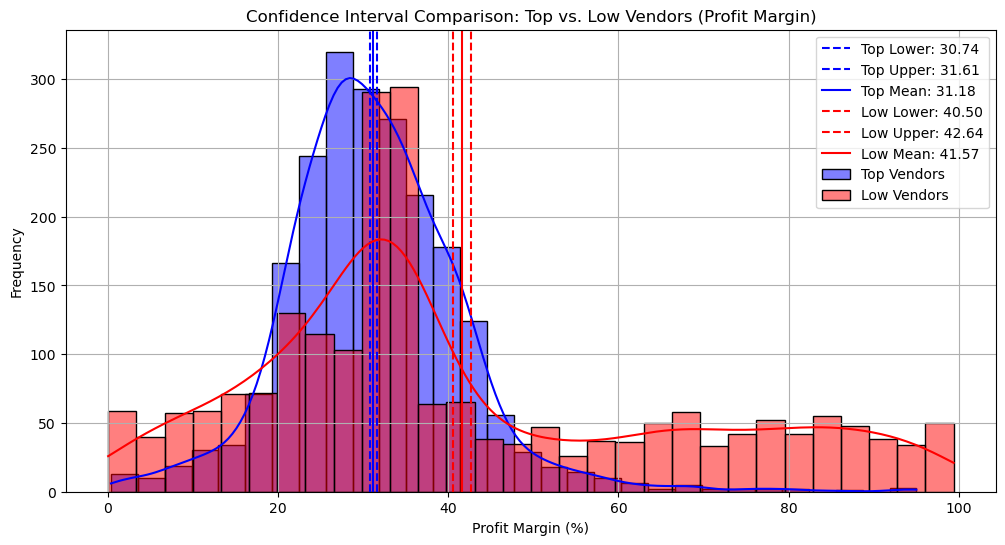

In [50]:
# Calculate confidence intervals for top and low vendors
top_mean, top_lower, top_upper = confidence_interval(top_vendors)
low_mean, low_lower, low_upper = confidence_interval(low_vendors)

# Print the results
print(f"Top Vendors 95% CI: ({top_lower:.2f}, {top_upper:.2f}), Mean: {top_mean:.2f}")
print(f"Low Vendors 95% CI: ({low_lower:.2f}, {low_upper:.2f}), Mean: {low_mean:.2f}")

# Plot histograms with confidence intervals
plt.figure(figsize=(12, 6))

# Top Vendors Plot
sns.histplot(top_vendors, kde=True, color="blue", bins=30, alpha=0.5, label="Top Vendors")
plt.axvline(top_lower, color="blue", linestyle="--", label=f"Top Lower: {top_lower:.2f}")
plt.axvline(top_upper, color="blue", linestyle="--", label=f"Top Upper: {top_upper:.2f}")
plt.axvline(top_mean, color="blue", linestyle="-", label=f"Top Mean: {top_mean:.2f}")

# Low Vendors Plot
sns.histplot(low_vendors, kde=True, color="red", bins=30, alpha=0.5, label="Low Vendors")
plt.axvline(low_lower, color="red", linestyle="--", label=f"Low Lower: {low_lower:.2f}")
plt.axvline(low_upper, color="red", linestyle="--", label=f"Low Upper: {low_upper:.2f}")
plt.axvline(low_mean, color="red", linestyle="-", label=f"Low Mean: {low_mean:.2f}")

# Finalize plot
plt.title("Confidence Interval Comparison: Top vs. Low Vendors (Profit Margin)")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

**Confidence Interval Insights**
-The confidence interval for low-performing vendors (40.48% to 42.62%) is significantly higher than that of top-performing vendors (30.74% to 31.61%).
-This suggests vendors with lower sales maintain higher profit margins, potentially due to premium pricing or lower operational costs.

**Recommendations:**
-High-Performing Vendors: Consider selective price adjustments, cost optimization, or bundling strategies to improve profitability.
-Low-Performing Vendors: Despite higher margins, low sales volume may indicate a need for better marketing, competitive pricing, or improved distribution strategies.

**Question:**
Is there a significant difference in profit margins between top-performing and low-performing vendors?

**Hypotheses:**

H₀ (Null Hypothesis): There is no significant difference in the mean profit margins of top-performing and low-performing vendors.

H₁ (Alternative Hypothesis): The mean profit margins of top-performing and low-performing vendors are significantly different.

In [51]:
from scipy.stats import ttest_ind

# Define thresholds for top and low vendors
top_threshold = df["TotalSalesDollars"].quantile(0.75)
low_threshold = df["TotalSalesDollars"].quantile(0.25)

# Filter top and low vendors by TotalSalesDollars and get ProfitMargin
top_vendors = df[df["TotalSalesDollars"] >= top_threshold]["ProfitMargin"].dropna()
low_vendors = df[df["TotalSalesDollars"] <= low_threshold]["ProfitMargin"].dropna()

# Perform Two-Sample T-Test
t_stat, p_value = ttest_ind(top_vendors, low_vendors, equal_var=False)

# Print results
print(f"T-Statistic: {t_stat:.4f}, P-Value: {p_value:.4f}")

if p_value < 0.05:
    print("Reject Ho: There is a significant difference in profit margins between top and low-performing vendors.")
else:
    print("Fail to Reject Ho: No significant difference in profit margins.")

T-Statistic: -17.6695, P-Value: 0.0000
Reject Ho: There is a significant difference in profit margins between top and low-performing vendors.


In [52]:
df.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio,UnitPurchasePrice,OrderSize,UnsoldInventoryValue
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5101919.51,672819.31,260999.20,1290667.91,25.297693,0.979108,1.338647,26.27,Large,79624.37
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4819073.49,561512.37,294438.66,1015032.27,21.062810,0.976890,1.266830,23.19,Large,87913.29
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4538120.60,461140.15,343854.07,1119816.92,24.675786,0.998575,1.327594,18.24,Large,4870.08
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4475972.88,420050.01,368242.80,1214774.94,27.139908,0.993703,1.372493,16.17,Large,20535.90
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4223107.62,545778.28,249587.83,1199901.61,28.412764,0.983556,1.396897,21.89,Large,49712.19


In [53]:
vendor_performance = df.groupby("VendorName").agg({
    "TotalSalesDollars": "sum",
    "TotalPurchaseDollars": "sum",
    "GrossProfit": "sum",
    "ProfitMargin": "mean",
    "StockTurnover": "mean"
}).reset_index()

vendor_performance.head()

,VendorName,TotalSalesDollars,TotalPurchaseDollars,GrossProfit,ProfitMargin,StockTurnover
0,ADAMBA IMPORTS INTL INC,704.53,446.16,258.37,36.672675,1.205128
1,ALISA CARR BEVERAGES,104470.94,25698.12,78772.82,75.526888,5.033621
2,ALTAMAR BRANDS LLC,15706.81,11706.20,4000.61,24.007483,0.979688
3,AMERICAN SPIRITS EXCHANGE,1511.16,934.08,577.08,38.187882,0.875000
4,AMERICAN VINTAGE BEVERAGE,139603.53,104435.68,35167.85,24.969833,0.962801


In [54]:
vendor_performance.to_csv("C:/Users/AB/Documents/projects/vendor_performance.csv", index=False)
print("✅ Vendor performance CSV saved!")

✅ Vendor performance CSV saved!
